# Agentic ML classification — end-to-end pipeline

This notebook walks through the full pipeline cell by cell, using the
same functions the CLI scripts (`scripts/run_orchestrator.py` etc.)
call — nothing here is reimplemented, it's the same
`agentic_ml.steps.*` / `agentic_ml.harness.*` code, just run one phase
at a time so you can see the intermediate output.

Pipeline: **intake** (optional — infers the target column from a
natural-language goal or the schema alone) → **profiler** (deterministic
facts + LLM narrative; its `recommended_split_strategy` drives the
split) → **split + leakage checks** → **modeling agent** (tries a few
candidate template+config proposals, each independently gated by two
deterministic leakage checks) → **verification agent** (a second-
opinion audit that reviews gate-passing candidates best-first and can
only flag/reject — never approve one that failed a gate — falling back
to the next-best candidate on a rejection) → **one locked test-set
evaluation** → **narrated summary**.

Requires a working `.env` (copy from `.env.example`) with `RIT_API_KEY`
/ `RIT_BASE_URL` set, or `MODEL_GATEWAY_BASE_URL` if using the gateway.
The API key is loaded but never printed anywhere in this notebook.

## 0. Setup — locate the repo, load `.env`, import everything

In [1]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "agentic_ml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (expected to find src/agentic_ml/ above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)  # so relative paths (datasets/raw/..., runs/, artifacts/...) match the CLI scripts
print(f"Repo root: {REPO_ROOT}")

Repo root: /home/ubuntupc/Documents/Github/agentic-ai-project/agentic-ml-classification


In [2]:
def load_env_file(path: Path) -> None:
    if not path.exists():
        print(f"No .env file found at {path} — assuming environment variables are already set.")
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip().strip('"').strip("'"))


load_env_file(REPO_ROOT / ".env")
assert os.environ.get("RIT_API_KEY") or os.environ.get("MODEL_GATEWAY_BASE_URL"), (
    "No RIT_API_KEY or MODEL_GATEWAY_BASE_URL found. Copy .env.example to .env and fill in "
    "RIT_API_KEY / RIT_BASE_URL (or the gateway vars) before running this notebook."
)
print("Environment loaded (secrets not printed).")

Environment loaded (secrets not printed).


In [3]:
from sklearn.base import clone
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

from agentic_ml.cli_common import make_run_dir, make_tracer, resolve_model_endpoint
from agentic_ml.harness.dataset import DatasetSpec, load_dataset, read_dataframe
from agentic_ml.harness.leaderboard import append_leaderboard_entry
from agentic_ml.harness.leakage import run_all_split_leakage_checks
from agentic_ml.harness.metrics import compute_metrics
from agentic_ml.harness.splits import make_split
from agentic_ml.harness.verification import build_review_bundle
from agentic_ml.model_client import ModelClient
from agentic_ml.steps.intake_step import run_intake_step
from agentic_ml.steps.modeling_step import run_modeling_step
from agentic_ml.steps.profiler_step import run_profiler_step
from agentic_ml.steps.verification_step import run_verification_step
from agentic_ml.templates.registry import get_template

print("Imports OK.")

Imports OK.


## 1. Configuration

Edit this cell for your dataset, then run everything below it in order.

- Leave `target_column` as `None` to let the **intake agent** infer it
  from `goal` (or from the schema alone if `goal` is also empty) — the
  "just a dataset" case.
- Set `target_column` explicitly to skip intake entirely.

In [4]:
CONFIG = {
    "data_path": "datasets/raw/train.csv",
    "goal": "predict whether a passenger survived the Titanic disaster",
    "target_column": None,        # e.g. "Survived" to skip intake
    "group_column": None,
    "time_column": None,
    "id_columns": None,           # comma-separated string, or None to let intake decide
    "strategy": None,             # None = use the profiler's recommendation
    "seed": 42,
    "metrics": ["roc_auc", "pr_auc", "f1", "accuracy"],
    "max_candidates": 2,
    "model": None,                # None = RIT_DEFAULT_MODEL env var
    "verification_model": None,   # None = a reasoning-oriented default, distinct from "model"
    "use_gateway": False,
    "run_id": None,               # None = auto-generate
}
CONFIG

{'data_path': 'datasets/raw/train.csv',
 'goal': 'predict whether a passenger survived the Titanic disaster',
 'target_column': None,
 'group_column': None,
 'time_column': None,
 'id_columns': None,
 'strategy': None,
 'seed': 42,
 'metrics': ['roc_auc', 'pr_auc', 'f1', 'accuracy'],
 'max_candidates': 2,
 'model': None,
 'verification_model': None,
 'use_gateway': False,
 'run_id': None}

## 2. Model client + run directory

In [5]:
base_url, api_key, default_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["model"], "qwen3-coder:30b", "rit-qwen3-coder-30b",
)
client = ModelClient(base_url=base_url, api_key=api_key, default_model=default_model)

run_id, run_dir = make_run_dir(CONFIG["run_id"])
trace = make_tracer(run_dir / "trace.jsonl")

print(f"run_id: {run_id}")
print(f"run_dir: {run_dir}")
print(f"model: {default_model}")

run_id: run_5377bc5e
run_dir: runs/run_5377bc5e
model: qwen3-coder:30b


## 3. Intake — figure out the dataset spec

Skipped if `CONFIG["target_column"]` is set. Otherwise the intake agent
sees only pre-target column facts (`get_raw_schema` — no target-dependent
stats exist yet) plus the natural-language `goal`, and proposes a
target/id/group/time column split. Its proposal is re-validated against
those same facts before anything downstream runs.

In [6]:
if CONFIG["target_column"] is None:
    raw_df = read_dataframe(CONFIG["data_path"])
    intake_result = run_intake_step(
        raw_df, CONFIG["goal"] or "", client, model=default_model,
        trace_fn=lambda r: trace(**r),
    )

    display(pd.DataFrame(intake_result.raw_schema["columns"]))
    print("IntakeAgent proposal:")
    print(json.dumps(intake_result.dataset_spec_proposal, indent=2))

    assert intake_result.ok, f"Intake proposal failed validation: {intake_result.validation_errors}"

    proposal = intake_result.dataset_spec_proposal
    target_column = proposal["target_column"]
    group_column = CONFIG["group_column"] or proposal.get("group_column")
    time_column = CONFIG["time_column"] or proposal.get("time_column")
    id_columns = proposal.get("id_columns") or []
else:
    target_column = CONFIG["target_column"]
    group_column = CONFIG["group_column"]
    time_column = CONFIG["time_column"]
    id_columns = [c.strip() for c in (CONFIG["id_columns"] or "").split(",") if c.strip()]

print(f"\ntarget_column={target_column!r}  group_column={group_column!r}  "
      f"time_column={time_column!r}  id_columns={id_columns}")

,name,dtype,missing_frac,n_unique,unique_frac,sample_values,name_suggests_id,name_suggests_group,looks_like_datetime
0,PassengerId,int64,0.0000,891,1.0000,"[1, 2, 3]",True,False,False
1,Survived,int64,0.0000,2,0.0022,"[0, 1, 1]",False,False,False
2,Pclass,int64,0.0000,3,0.0034,"[3, 1, 3]",False,False,False
3,Name,object,0.0000,891,1.0000,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B...",False,False,False
4,Sex,object,0.0000,2,0.0022,"[male, female, female]",False,False,False
5,Age,float64,0.1987,88,0.0988,"[22.0, 38.0, 26.0]",False,False,False
6,SibSp,int64,0.0000,7,0.0079,"[1, 1, 0]",False,False,False
7,Parch,int64,0.0000,7,0.0079,"[0, 0, 0]",False,False,False
8,Ticket,object,0.0000,681,0.7643,"[A/5 21171, PC 17599, STON/O2. 3101282]",False,False,False
9,Fare,float64,0.0000,248,0.2783,"[7.25, 71.2833, 7.925]",False,False,False


IntakeAgent proposal:
{
  "target_column": "Survived",
  "task": "binary_classification",
  "id_columns": [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
  ],
  "group_column": null,
  "time_column": null,
  "positive_label": 1,
  "reasoning": "The 'Survived' column is the target because it directly represents the outcome of interest - whether a passenger survived the disaster. The 'PassengerId', 'Name', 'Ticket', and 'Cabin' columns are excluded as identifiers or unique attributes that would not be predictive of survival. The 'Survived' column has exactly 2 unique values (0 and 1) as required for binary classification."
}

target_column='Survived'  group_column=None  time_column=None  id_columns=['PassengerId', 'Name', 'Ticket', 'Cabin']


## 4. Load the dataset + Profiler agent

Deterministic code computes every fact (`harness/profiler.py`); the LLM
only narrates and recommends — it cannot change `recommended_split_strategy`
or the leakage risk flags.

In [7]:
spec = DatasetSpec(
    path=CONFIG["data_path"], target_column=target_column,
    group_column=group_column, time_column=time_column, id_columns=id_columns,
)
loaded = load_dataset(spec)
display(loaded.df.head())
print(f"{len(loaded.df)} rows, {len(loaded.df.columns)} columns, data_hash={loaded.data_hash[:16]}...")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


891 rows, 12 columns, data_hash=1379e5d8a660488f...


In [8]:
profiler_result = run_profiler_step(
    loaded.df, target_column, client, model=default_model,
    trace_fn=lambda r: trace(**r),
)
assert profiler_result.ok, "ProfilerAgent never called get_dataset_profile."

dr = profiler_result.deterministic_report
display(pd.DataFrame(dr["columns"]))
print(f"recommended_split_strategy: {dr['recommended_split_strategy']}")
print(f"is_imbalanced: {dr['is_imbalanced']}  (ratio={dr['class_imbalance_ratio']})")
print(f"leakage_risk_flags: {dr['leakage_risk_flags']}")

display(Markdown(f"**Profiler narrative:**\n\n{profiler_result.llm_narrative.get('summary', '') if profiler_result.llm_narrative else profiler_result.llm_raw_text}"))

,name,dtype,missing_count,missing_frac,n_unique,unique_frac,is_likely_id,is_likely_categorical,is_likely_numeric,is_likely_datetime,is_likely_group_candidate,sample_values
0,PassengerId,int64,0,0.0000,891,1.0000,True,False,True,False,False,"[1, 2, 3]"
1,Survived,int64,0,0.0000,2,0.0022,False,True,False,False,False,"[0, 1, 1]"
2,Pclass,int64,0,0.0000,3,0.0034,False,True,False,False,False,"[3, 1, 3]"
3,Name,object,0,0.0000,891,1.0000,True,False,False,False,False,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
4,Sex,object,0,0.0000,2,0.0022,False,True,False,False,False,"[male, female, female]"
5,Age,float64,177,0.1987,88,0.0988,False,False,True,False,False,"[22.0, 38.0, 26.0]"
6,SibSp,int64,0,0.0000,7,0.0079,False,True,False,False,False,"[1, 1, 0]"
7,Parch,int64,0,0.0000,7,0.0079,False,True,False,False,False,"[0, 0, 0]"
8,Ticket,object,0,0.0000,681,0.7643,False,False,False,False,False,"[A/5 21171, PC 17599, STON/O2. 3101282]"
9,Fare,float64,0,0.0000,248,0.2783,False,False,True,False,False,"[7.25, 71.2833, 7.925]"


recommended_split_strategy: stratified
is_imbalanced: False  (ratio=0.623)
leakage_risk_flags: ["columns with >50% missing values (consider excluding via id_columns): ['Cabin']"]


**Profiler narrative:**

The dataset contains 891 passenger records from the Titanic disaster with 12 columns including passenger details like age, sex, class, and survival status. The target variable 'Survived' is imbalanced with 61.6% of passengers not surviving. The dataset has several columns with missing values, most notably 'Cabin' which is 77.1% missing. Key identifying columns include 'PassengerId' and 'Name'.

## 5. Split + split-level leakage checks

In [9]:
strategy = CONFIG["strategy"] or dr["recommended_split_strategy"]
print(f"Split strategy: {strategy} ({'explicit override' if CONFIG['strategy'] else 'profiler recommendation'})")

manifest = make_split(
    df=loaded.df, target_column=target_column, data_hash=loaded.data_hash,
    strategy=strategy, seed=CONFIG["seed"], group_column=group_column, time_column=time_column,
)
print(f"train={len(manifest.train_idx)}  val={len(manifest.val_idx)}  test={len(manifest.test_idx)}")
display(pd.DataFrame(manifest.target_distribution))

Split strategy: stratified (profiler recommendation)
train=625  val=133  test=133


,train,val,test
0,0.616,0.6165,0.6165
1,0.384,0.3835,0.3835


In [10]:
leakage_checks = run_all_split_leakage_checks(
    df=loaded.df, group_column=group_column, time_column=time_column,
    train_idx=manifest.train_idx, val_idx=manifest.val_idx, test_idx=manifest.test_idx,
    strategy=strategy,
)
leakage_df = pd.DataFrame([c.to_dict() for c in leakage_checks])
display(leakage_df)

assert all(c.passed for c in leakage_checks), "Split-level leakage check failed — stopping here."
print("All split-level leakage checks passed.")

,check,passed,detail
0,duplicate_rows_across_splits,True,no exact duplicate rows across splits
1,group_overlap,True,"no group_column declared, check skipped"
2,time_ordering,True,"no time_column declared, check skipped"


All split-level leakage checks passed.


## 6. Modeling agent — propose & evaluate candidates

Each candidate: the agent picks a verified recipe template and fills in
its config (feature columns, a few hyperparameters) — it never writes
pipeline code. The harness then re-validates every proposed column
against the profiler's facts, static-checks + sandbox-builds the
template, fits/scores it on the train/val split, and requires TWO
independent leakage checks to both pass: `label_permutation_test`
(pipeline-level leakage) and `check_suspicious_feature_correlation`
scoped to exactly this candidate's selected columns (raw feature-level
leakage). `ok=True` means "passed both gates", not just "no errors".

In [11]:
metric_names = CONFIG["metrics"]
primary_metric = metric_names[0]
candidate_results = []
tried_template_ids = []

for i in range(CONFIG["max_candidates"]):
    print(f"\n=== ModelingAgent candidate {i + 1}/{CONFIG['max_candidates']} ===")
    step_result = run_modeling_step(
        full_df=loaded.df, X=loaded.X, y=loaded.y, target_column=target_column,
        group_column=group_column, time_column=time_column,
        train_idx=manifest.train_idx, val_idx=manifest.val_idx,
        client=client, model=default_model, metric_names=metric_names, seed=CONFIG["seed"],
        already_tried_template_ids=tried_template_ids,
        trace_fn=lambda r: trace(**r),
    )
    if step_result.template_id:
        tried_template_ids.append(step_result.template_id)
    candidate_results.append(step_result)

    print(f"candidate_id={step_result.candidate_id}  template={step_result.template_id}")
    if step_result.explanation:
        print(f"explanation: {step_result.explanation}")

    if step_result.ok:
        print(f"PASSED both leakage gates — {primary_metric}={step_result.metrics[primary_metric]['value']:.4f}")
    else:
        print(f"REJECTED by harness gates: {step_result.errors}")

rows = []
for r in candidate_results:
    row = {"candidate_id": r.candidate_id, "template_id": r.template_id, "passed_gate": r.ok}
    if r.metrics:
        row.update({m: v["value"] for m, v in r.metrics.items()})
    rows.append(row)

comparison_df = pd.DataFrame(rows)
display(comparison_df)


=== ModelingAgent candidate 1/2 ===
candidate_id=sklearn_mixed_pipeline_titanic  template=sklearn_mixed_pipeline
explanation: The dataset has a mix of numeric and categorical columns, with categorical columns having low-to-moderate cardinality (<=30 unique values), making the 'sklearn_mixed_pipeline' template appropriate. The target 'Survived' is not imbalanced, so we don't need specialized handling for imbalance. We exclude 'PassengerId' and 'Name' as they are likely ID columns, and 'Cabin' due to high missingness. The numeric columns 'Age' and 'Fare' are included, and the categorical columns 'Pclass', 'Sex', 'SibSp', 'Parch', and 'Embarked' are included as they are suitable for one-hot encoding in this pipeline.
PASSED both leakage gates — roc_auc=0.8274

=== ModelingAgent candidate 2/2 ===
candidate_id=lightgbm_mixed_candidate  template=lightgbm_mixed
explanation: The dataset has a mix of numeric and categorical columns, with categorical columns having moderate cardinality (e.g., '

,candidate_id,template_id,passed_gate,roc_auc,pr_auc,f1,accuracy
0,sklearn_mixed_pipeline_titanic,sklearn_mixed_pipeline,True,0.827355,0.826182,0.760870,0.834586
1,lightgbm_mixed_candidate,lightgbm_mixed,True,0.865136,0.849180,0.742268,0.812030


## 7. Verification agent — second-opinion audit, best candidate first

Reviews each gate-passing candidate in validation-`primary_metric`
order and can only make the outcome MORE conservative than "the gates
passed": `"flagged"` (proceed, concern recorded) or `"rejected"`
(blocked — fall back to the next-best candidate). It never sees, and
can never approve, a candidate that already failed a harness gate.
Every reviewed candidate is logged to the leaderboard with its
verdict.

In [12]:
_, _, verification_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["verification_model"], "gemma4:latest", "rit-gemma4-latest",
)
print(f"verification_model: {verification_model}")

passing = [r for r in candidate_results if r.ok]
assert passing, "No candidate passed the harness's deterministic leakage gates — nothing to promote."

ranked = sorted(passing, key=lambda r: r.metrics[primary_metric]["value"], reverse=True)
leaderboard_path = Path("artifacts/reports/leaderboard.jsonl")

best = None
selected_verification = None
verification_rows = []

for candidate in ranked:
    print(f"\nVerificationAgent reviewing {candidate.candidate_id}...")
    template = get_template(candidate.template_id)
    bundle = build_review_bundle(
        candidate_id=candidate.candidate_id, template_id=candidate.template_id,
        template_description=template.description, template_when_to_use=template.when_to_use,
        config=candidate.config, explanation=candidate.explanation,
        metrics=candidate.metrics, label_permutation_check=candidate.label_permutation_check,
        feature_correlation_check=candidate.feature_correlation_check,
        profiler_report=dr,
    )
    v_result = run_verification_step(
        bundle, client, model=verification_model, trace_fn=lambda r: trace(**r),
    )
    print(f"  verdict: {v_result.verdict}"
          + (f"  concerns: {v_result.concerns}" if v_result.concerns else ""))

    verification_rows.append({
        "candidate_id": candidate.candidate_id, "verdict": v_result.verdict,
        "concerns": "; ".join(v_result.concerns) if v_result.concerns else "",
    })

    append_leaderboard_entry(leaderboard_path, {
        "run_id": run_id, "candidate": candidate.candidate_id, "template_id": candidate.template_id,
        "source": "notebook", "model": default_model, "split": "validation", "strategy": strategy,
        "data_hash": loaded.data_hash, "seed": CONFIG["seed"], "metrics": candidate.metrics,
        "verification_verdict": v_result.verdict,
    })

    if v_result.verdict == "rejected":
        print("  REJECTED — trying the next-best candidate.")
        continue
    best = candidate
    selected_verification = v_result
    break

display(pd.DataFrame(verification_rows))
assert best is not None, "Every gate-passing candidate was rejected by the VerificationAgent."
print(f"\nSelected: {best.candidate_id} ({best.template_id}) — "
      f"{primary_metric}={best.metrics[primary_metric]['value']:.4f} on validation "
      f"(verification: {selected_verification.verdict})")

verification_model: qwen3-coder:30b

VerificationAgent reviewing lightgbm_mixed_candidate...
  verdict: approved


,candidate_id,verdict,concerns
0,lightgbm_mixed_candidate,approved,



Selected: lightgbm_mixed_candidate (lightgbm_mixed) — roc_auc=0.8651 on validation (verification: approved)


## 8. Final test-set evaluation

The accepted candidate is refit on train+val combined, then the
**locked test set is touched exactly once**.

In [13]:
train_and_val_idx = sorted(manifest.train_idx + manifest.val_idx)
final_pipeline = clone(best.pipeline)
final_pipeline.fit(loaded.X.iloc[train_and_val_idx], loaded.y.iloc[train_and_val_idx])

y_test = loaded.y.iloc[manifest.test_idx]
y_pred = final_pipeline.predict(loaded.X.iloc[manifest.test_idx])
proba = final_pipeline.predict_proba(loaded.X.iloc[manifest.test_idx])
y_proba = proba[:, 1] if proba.shape[1] == 2 else proba.max(axis=1)

test_results = compute_metrics(y_test.values, y_pred, y_proba, metric_names, n_bootstrap=200, seed=CONFIG["seed"])
test_metrics_df = pd.DataFrame([r.to_dict() for r in test_results.values()]).set_index("metric")
display(test_metrics_df)
print("\nNOTE: this is the only time the test split is touched.")

,value,ci_low,ci_high,n_bootstrap
metric,,,,
roc_auc,0.872071,0.805591,0.933221,200
pr_auc,0.849890,0.767324,0.911351,200
f1,0.712871,0.603679,0.800115,200
accuracy,0.781955,0.706767,0.842293,200



NOTE: this is the only time the test split is touched.


## 9. ROC curve + confusion matrix (test set)

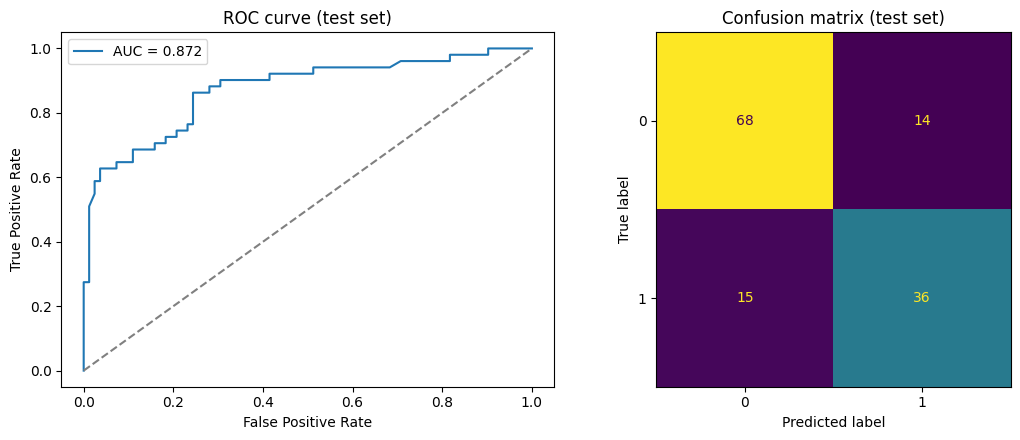

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve (test set)")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix (test set)")

plt.tight_layout()
plt.show()

## 10. Narrated summary

Plain-text only — no tools, no decisions, just narrating facts already computed above.

In [15]:
summary_messages = [
    {"role": "system", "content": (
        "You are the Analyst step of a deterministic ML pipeline. Respond "
        "with 4-6 sentences of plain prose only (no JSON, no markdown "
        "fences) summarizing the given facts for a non-technical "
        "stakeholder. Do not invent any numbers not present in the input."
    )},
    {"role": "user", "content": json.dumps({
        "goal": CONFIG["goal"] or "(none given — target inferred from data alone)",
        "target_column": target_column,
        "n_candidates_tried": len(candidate_results),
        "n_candidates_passed_leakage_gate": len(passing),
        "selected_candidate": {
            "candidate_id": best.candidate_id, "template_id": best.template_id,
            "verification_verdict": selected_verification.verdict,
        },
        "final_test_metrics": {m: test_results[m].to_dict() for m in metric_names},
        "note_for_summary": (
            "Mention the verification concerns briefly as a caveat for human review."
            if selected_verification.concerns else None
        ),
    }, indent=2)},
]
summary_response = client.call(summary_messages, model=default_model, max_tokens=400)
display(Markdown(f"**Summary:**\n\n{summary_response.text}"))

**Summary:**

The machine learning model successfully predicted whether passengers survived the Titanic disaster using a LightGBM approach that handled both numerical and categorical data types. The model achieved an ROC AUC score of 0.872, which indicates good discriminative ability in distinguishing survivors from non-survivors. Performance was evaluated using multiple metrics including accuracy at 0.782 and F1 score at 0.713, with confidence intervals providing a range of expected performance. The model passed all data leakage checks, ensuring that it won't overfit to the training data. These results suggest the model has strong predictive power for this historical survival prediction task.

## 11. Write a report + list this run's artifacts

In [16]:
report = {
    "run_id": run_id, "model": default_model, "status": "success",
    "target_column": target_column,
    "selected_candidate": {
        "candidate_id": best.candidate_id, "template_id": best.template_id,
        "verification_verdict": selected_verification.verdict,
        "verification_concerns": selected_verification.concerns,
    },
    "final_test_metrics": {m: test_results[m].to_dict() for m in metric_names},
    "final_summary": summary_response.text,
}
(run_dir / "notebook_report.json").write_text(json.dumps(report, indent=2, default=str))
print(f"Report written to {run_dir / 'notebook_report.json'}")

print("\nFiles written this run:")
for p in sorted(run_dir.rglob("*")):
    if p.is_file():
        print(" ", p)  # already relative — we chdir'd to REPO_ROOT in cell 0

Report written to runs/run_5377bc5e/notebook_report.json

Files written this run:
  runs/run_5377bc5e/notebook_report.json
  runs/run_5377bc5e/trace.jsonl
